# Ableton Project Notebook

### Notebook Runtime

##### Updated 11/2024

#### Local
* should work with same python3 environment as parse_projects.py 

#### Colab:
* run `./ableton_projects/start_notebook.sh` to start
server on `8888`
* see `start_notebook.sh` for installing python2 kernel and packages
* see https://research.google.com/colaboratory/local-runtimes.html


### Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import parse_projects as parser
print(f"Python Version:\n  {parser.PYTHON_VERSION}")


Python Version:
  3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


### Load Parsed Projects

In [2]:
#@title Get info for all Projects and cache

# Load projects using default args should work if notebook is in project dir.
load_most_recent_cached = True #@param {type:"boolean"}
project_dir = "./" #@param {type:"string"}
# Overwrite parser defaults
# SKIP_FOLDERS = [ 'Backup', 'old', 'Samples', 'Ableton Project Info', '.git'] #@param {type:"raw"}
# CACHE_DIR = "./logs/" #@param {type:"string"}


# Load from recent cache (fast)
if load_most_recent_cached: 
  project_info = parser.load_info(prefix=parser.CACHE_INFO_FILE, load_most_recent=True)
  project_errors = parser.load_info(prefix=parser.CACHE_ERROR_FILE, load_most_recent=True)
  project_counters = parser.load_dict_from_json(parser.COUNTER_JSON)

# Parse project .als files
else:
  project_info, project_errors, project_counters = parser.run_parser(project_dir)

if len(project_errors):
  print('Projects missing info due to errors')
  parser.print_dict(project_errors)

Loading project_info from 2024-11-29 22:02:04.
Loaded 466 project_info in 0.02 seconds.
  No cache files found matching prefix: project_errors
Loading json: logs/counters.json.


# Analysis

### TODO
* save a csv with all the project stats (see project dict but del tracks field), row per als project
* make a 11 version for all 12, rename 12 to have 12 in name, or remove if not adding value
* reduce Au usage as much as possible, prefer vst or vst3 (not sure if code supports vst3 but neutron au can be a vst3)
* address todos below
* archive a10 projects that have working a11 copy,
* archive other copies to Backup folder, ideally one copy per project (or more for variations track vs dj)

Counter: ableton_versions has 3 entries


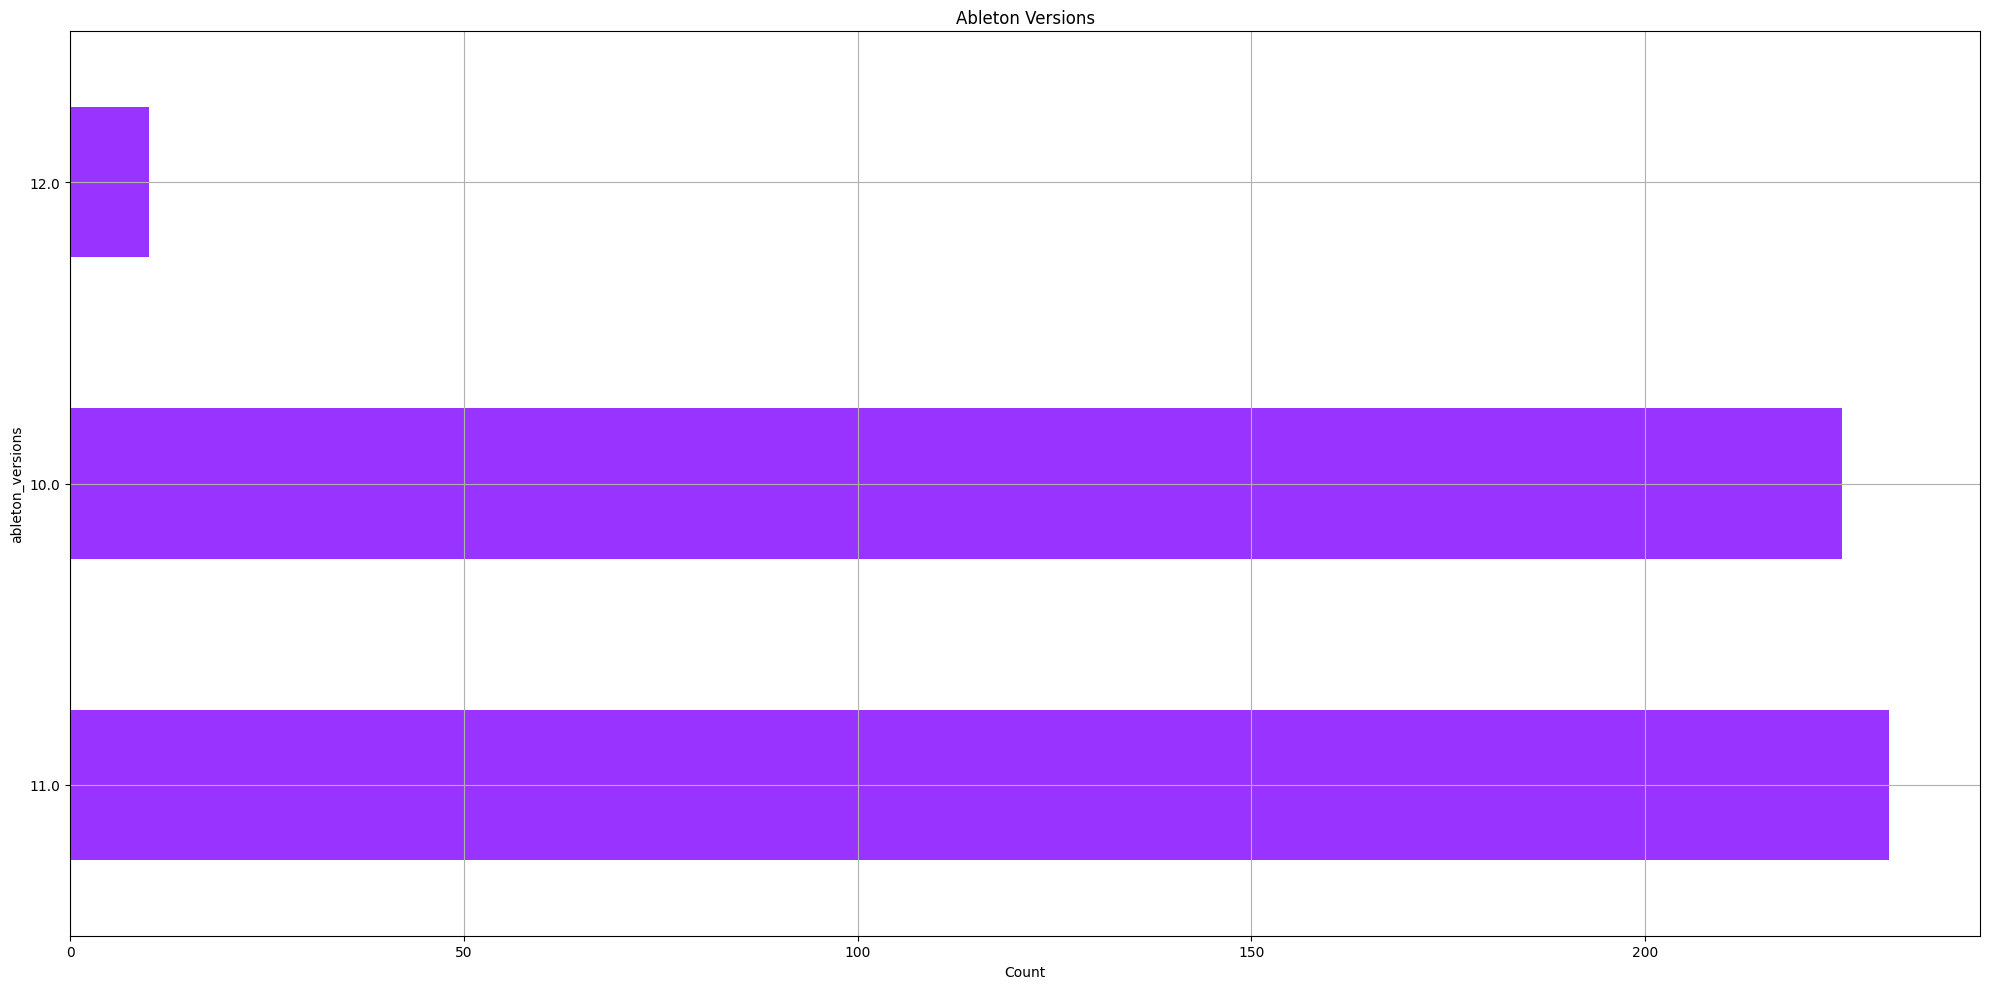

Counter: creation_years has 6 entries


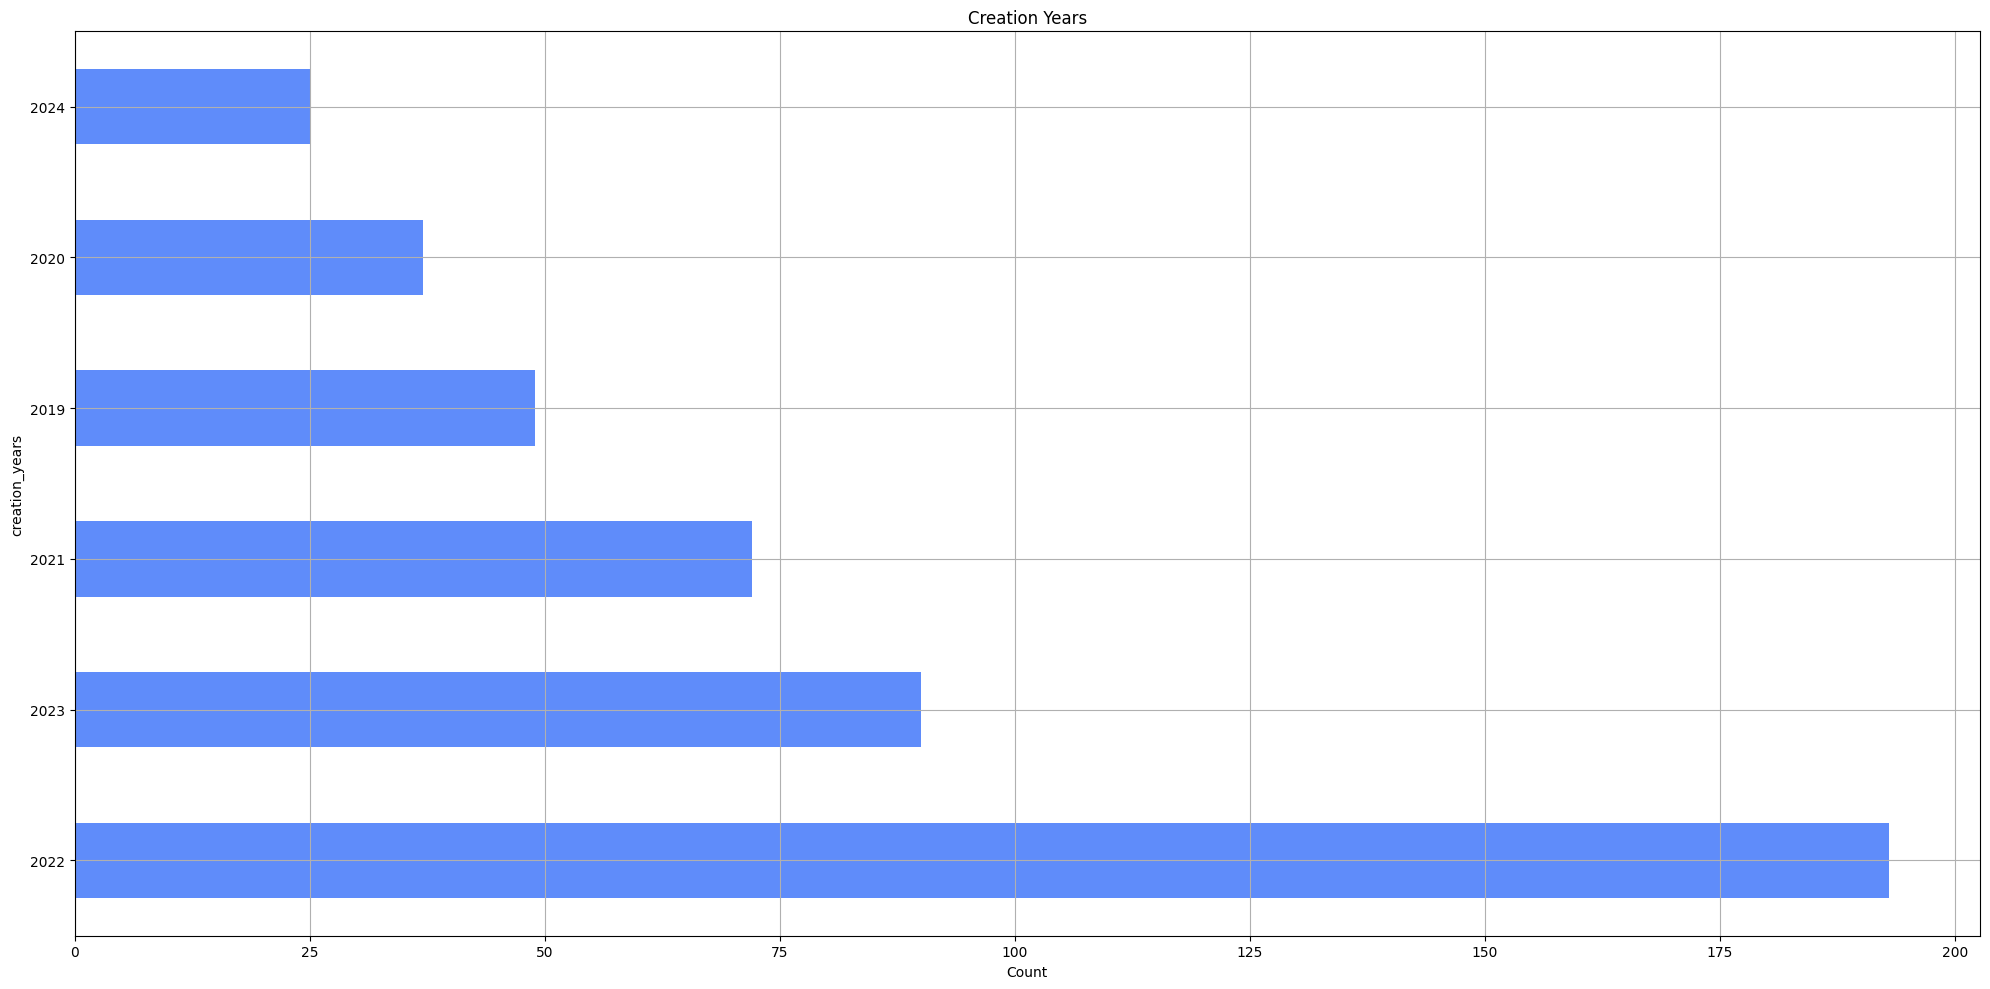

Counter: device_types has 56 entries


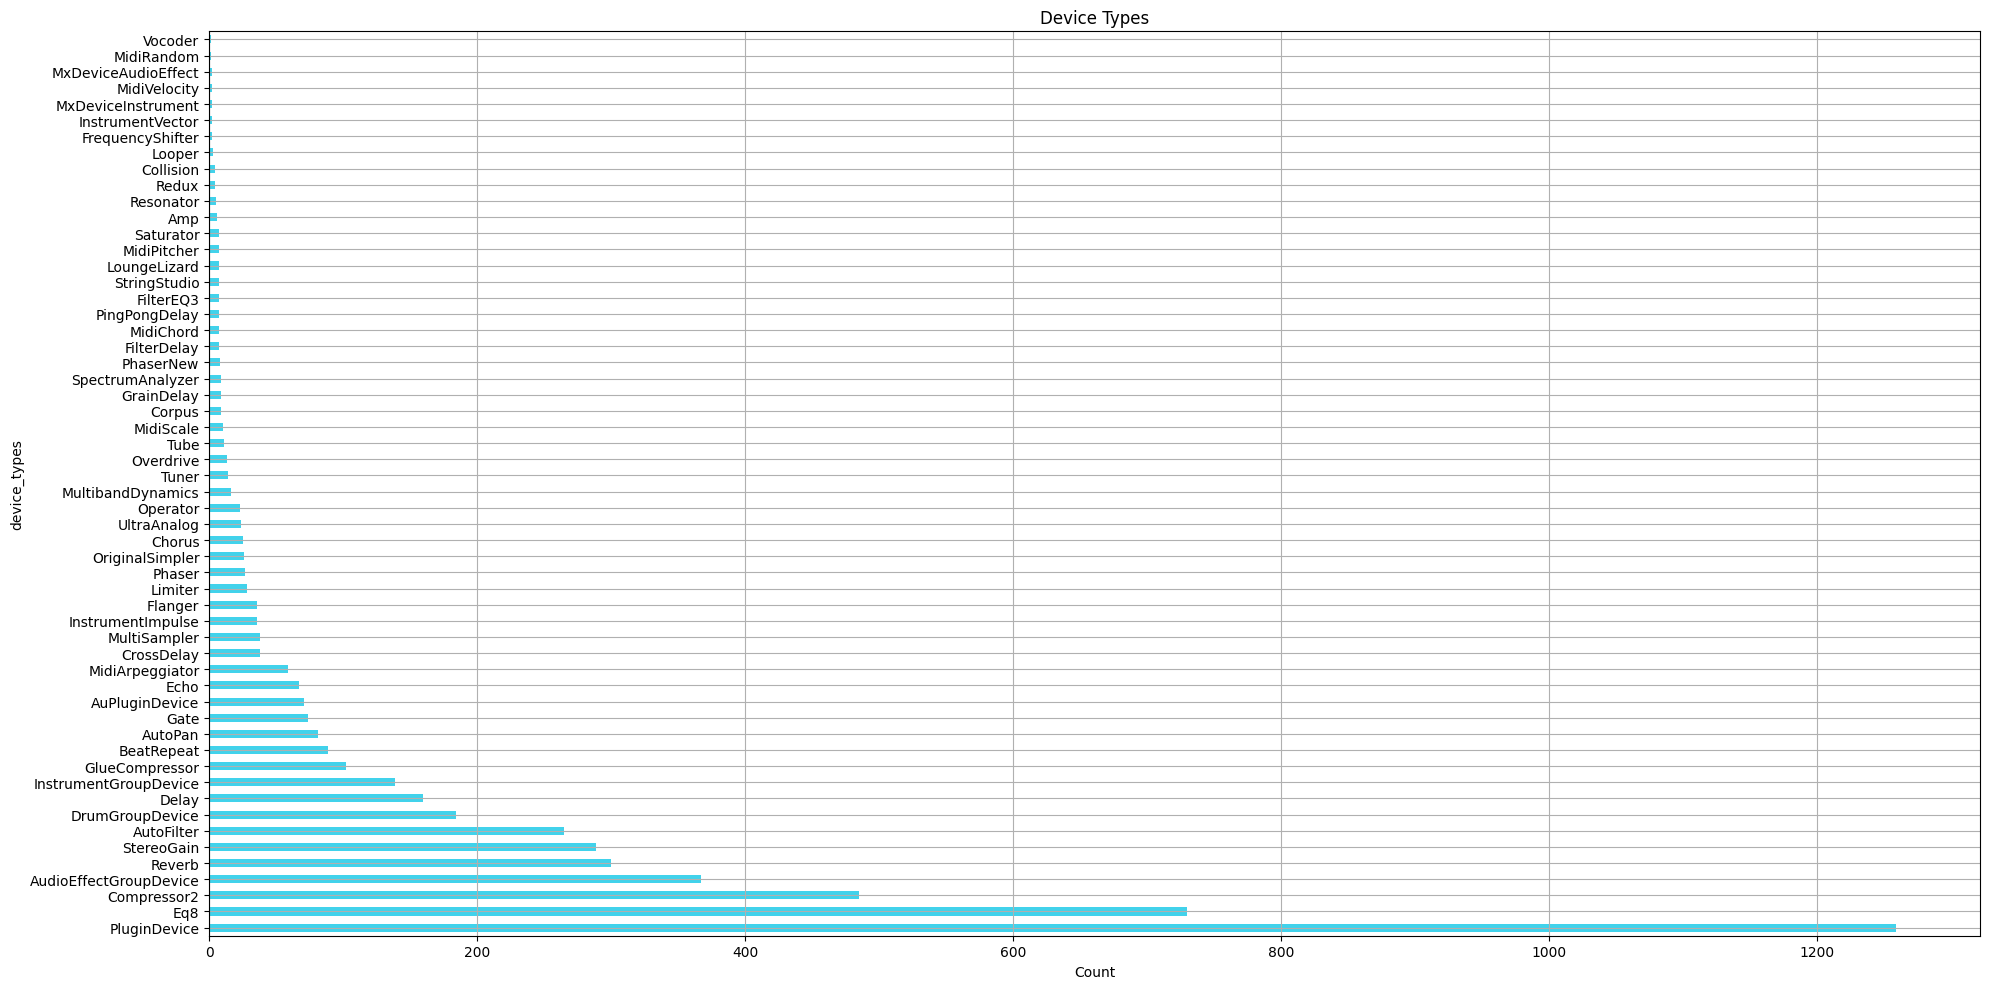

Counter: last_modified_years has 7 entries


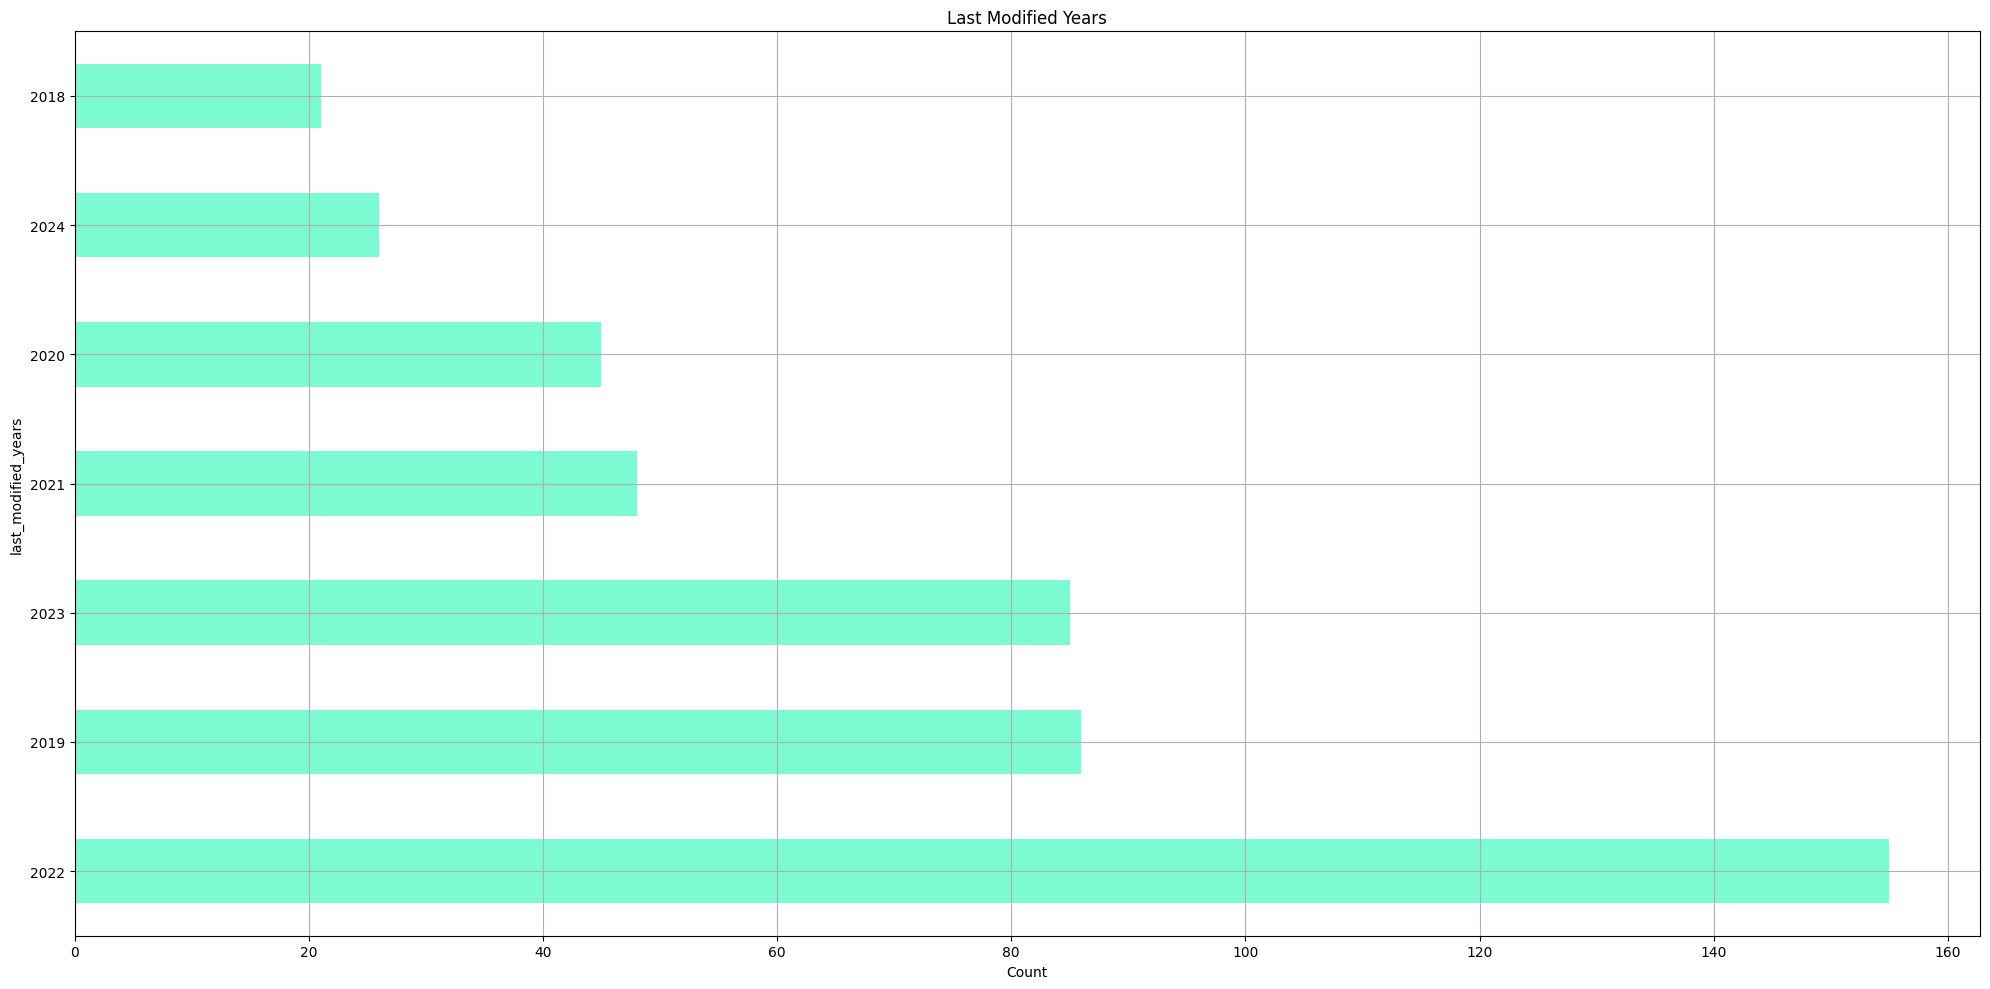

Counter: plugins_au has 8 entries


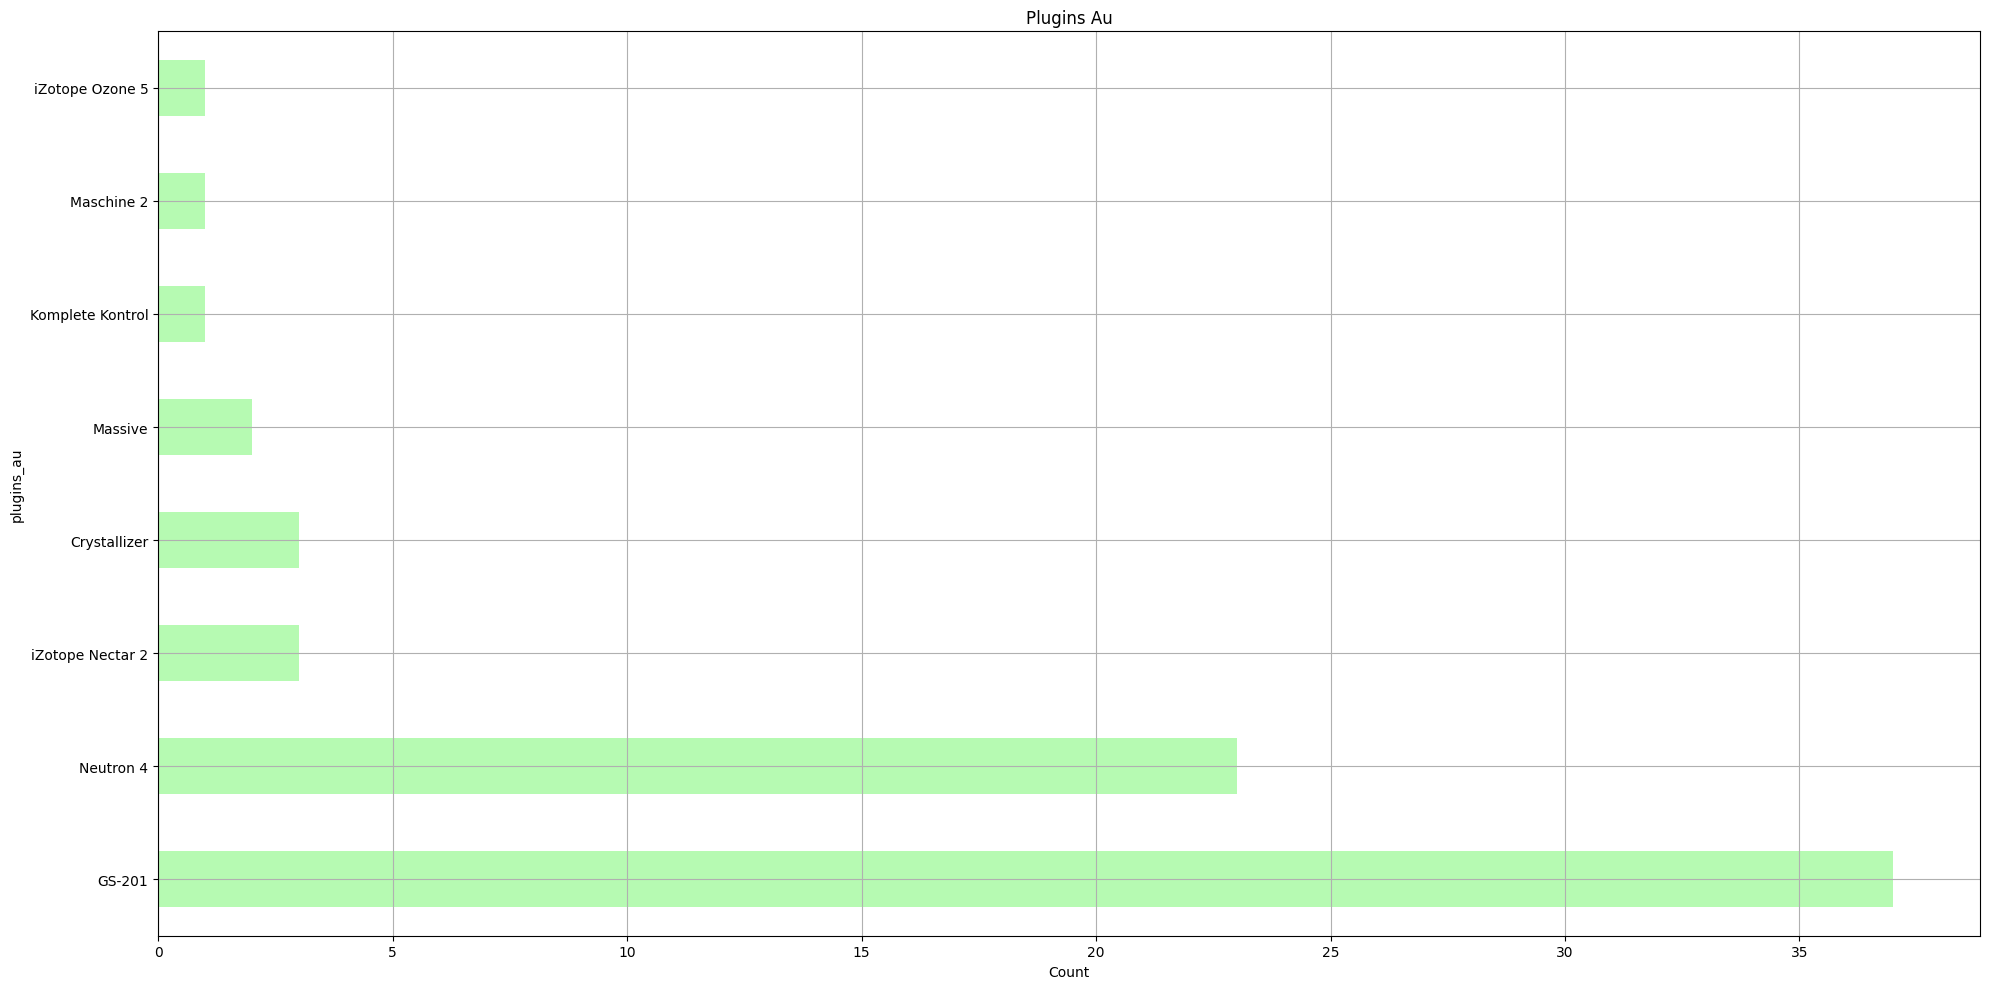

Counter: plugins_vst has 48 entries


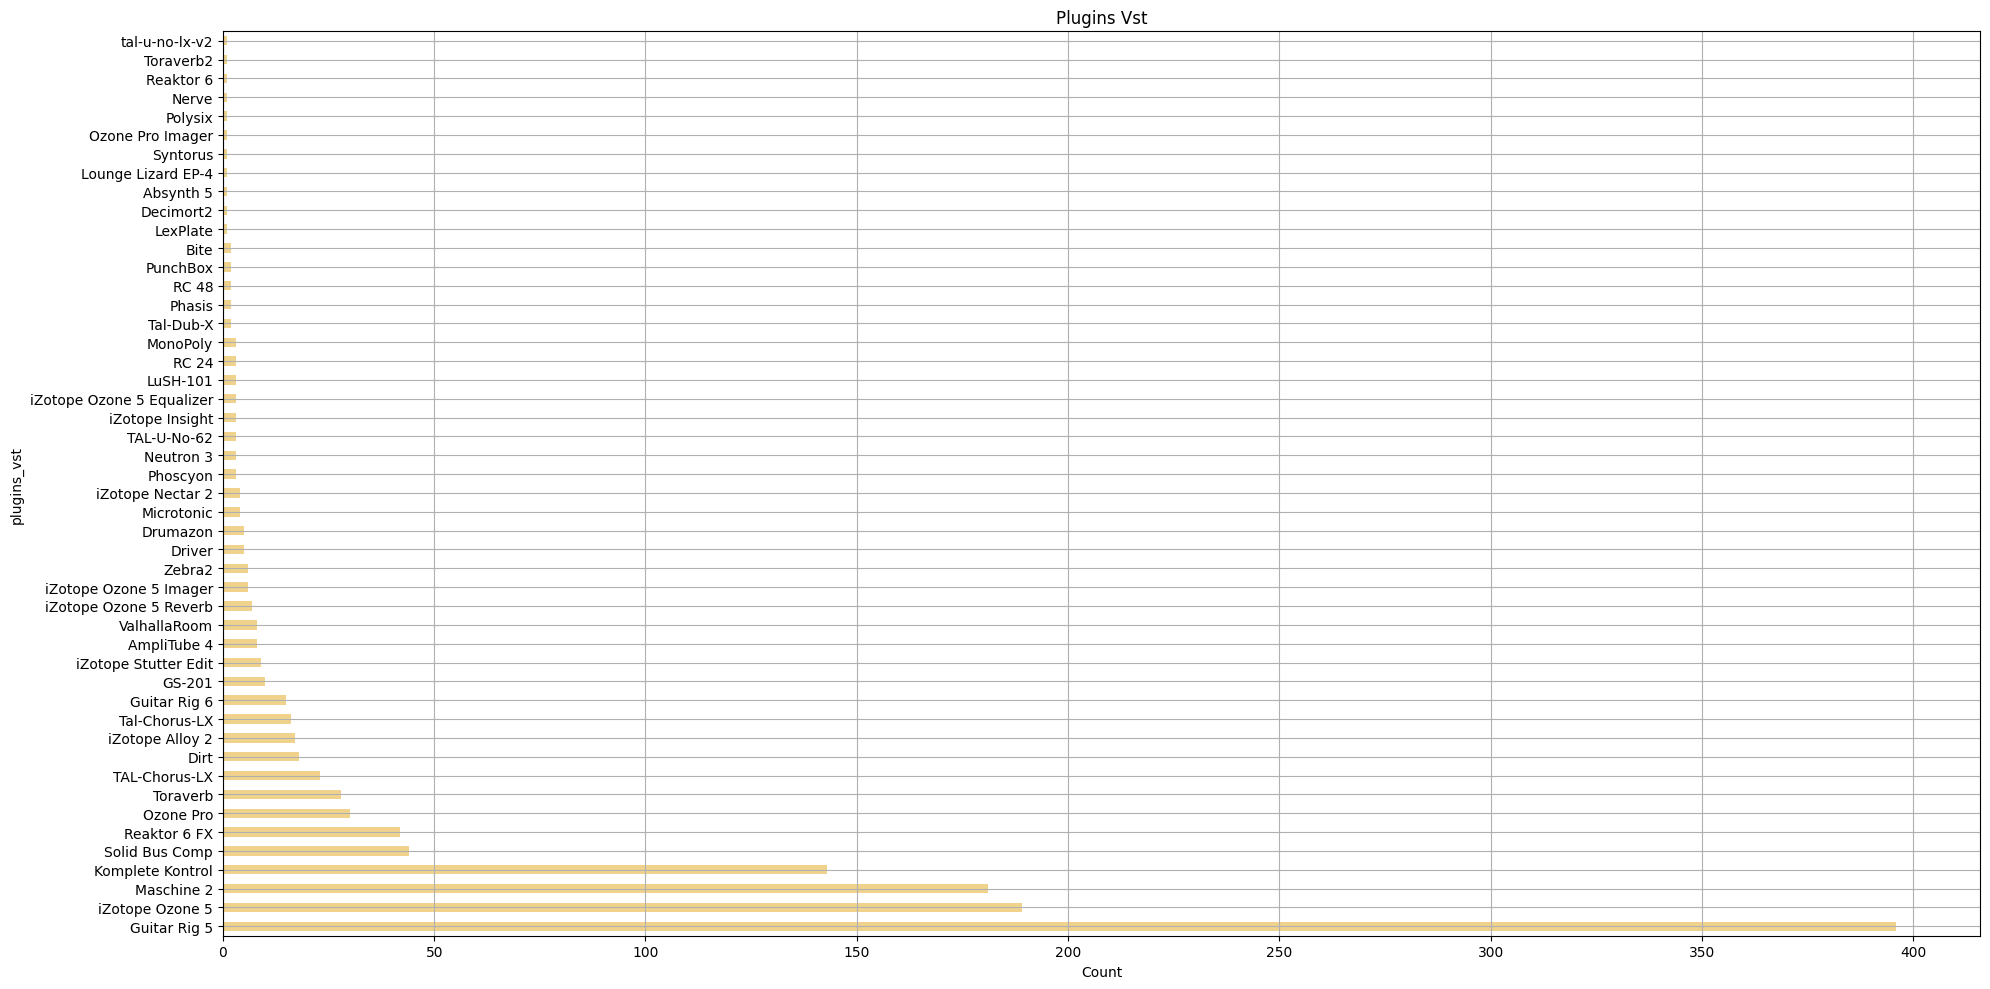

Counter: track_counts has 33 entries


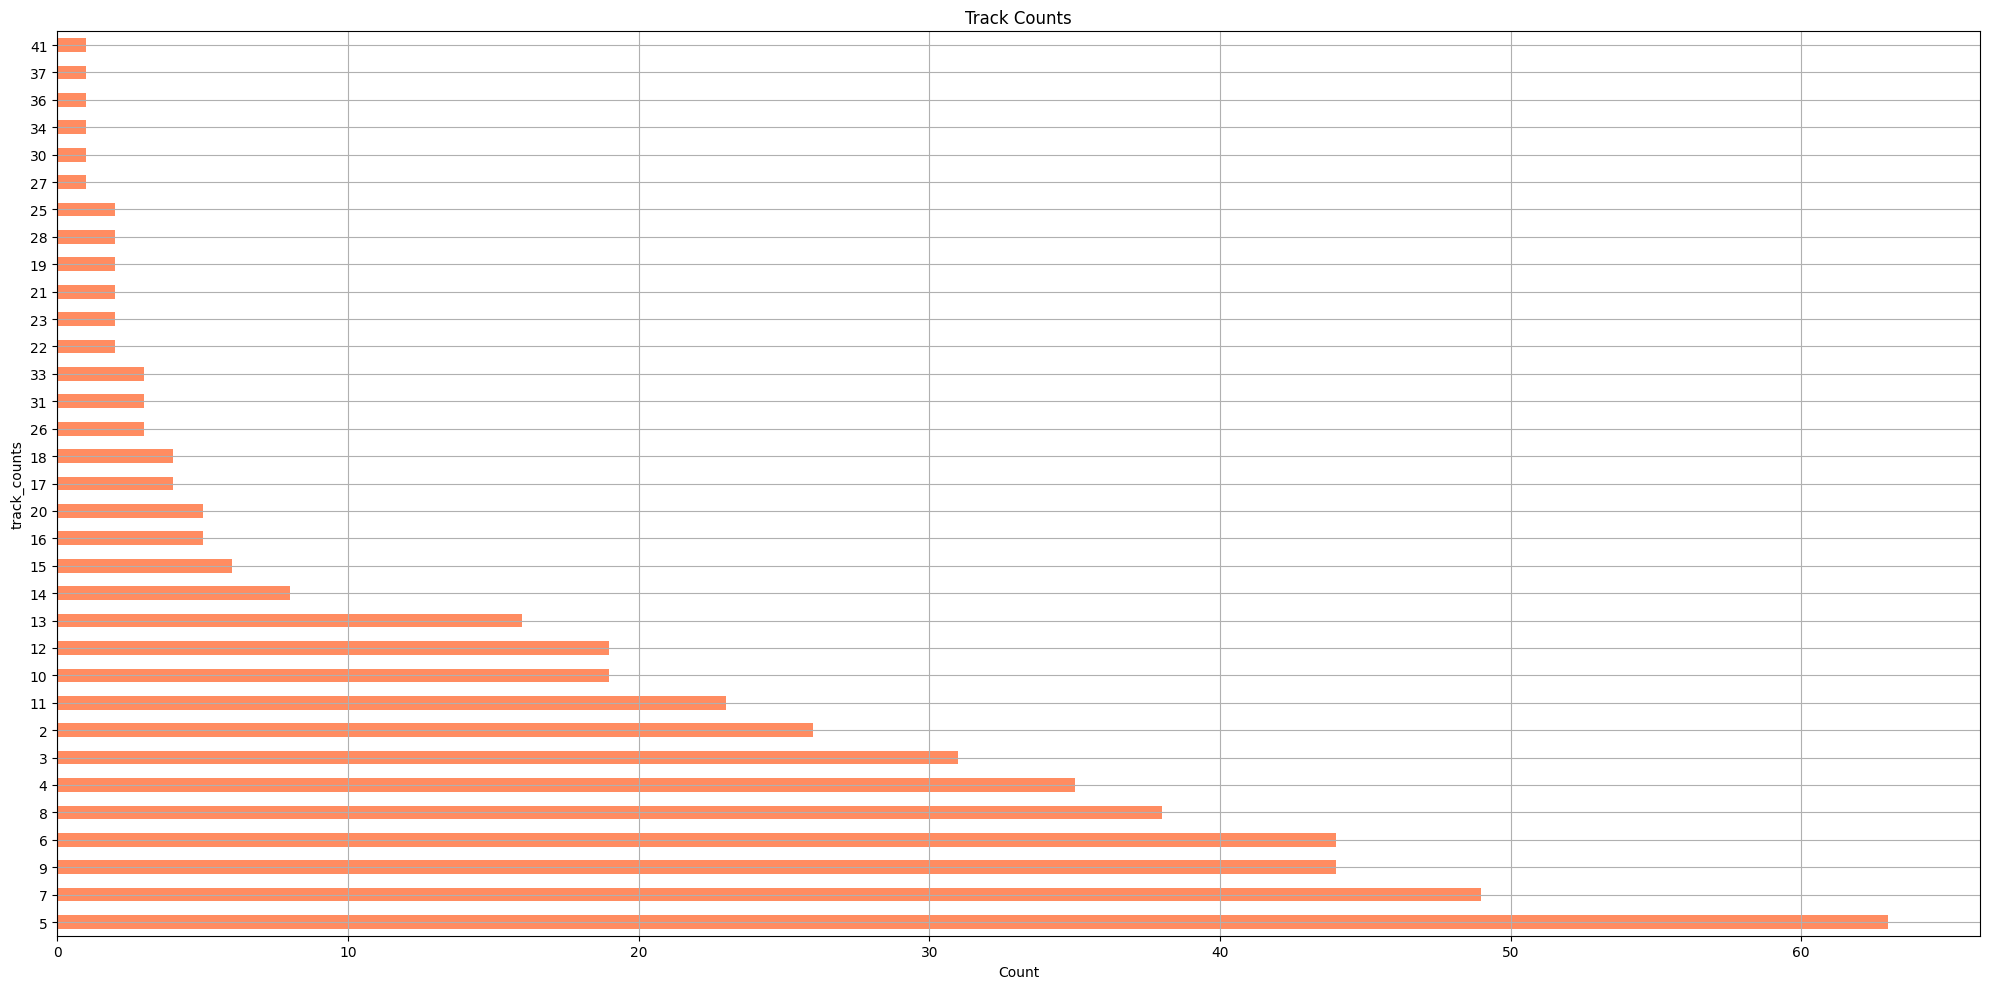

Counter: track_types has 5 entries


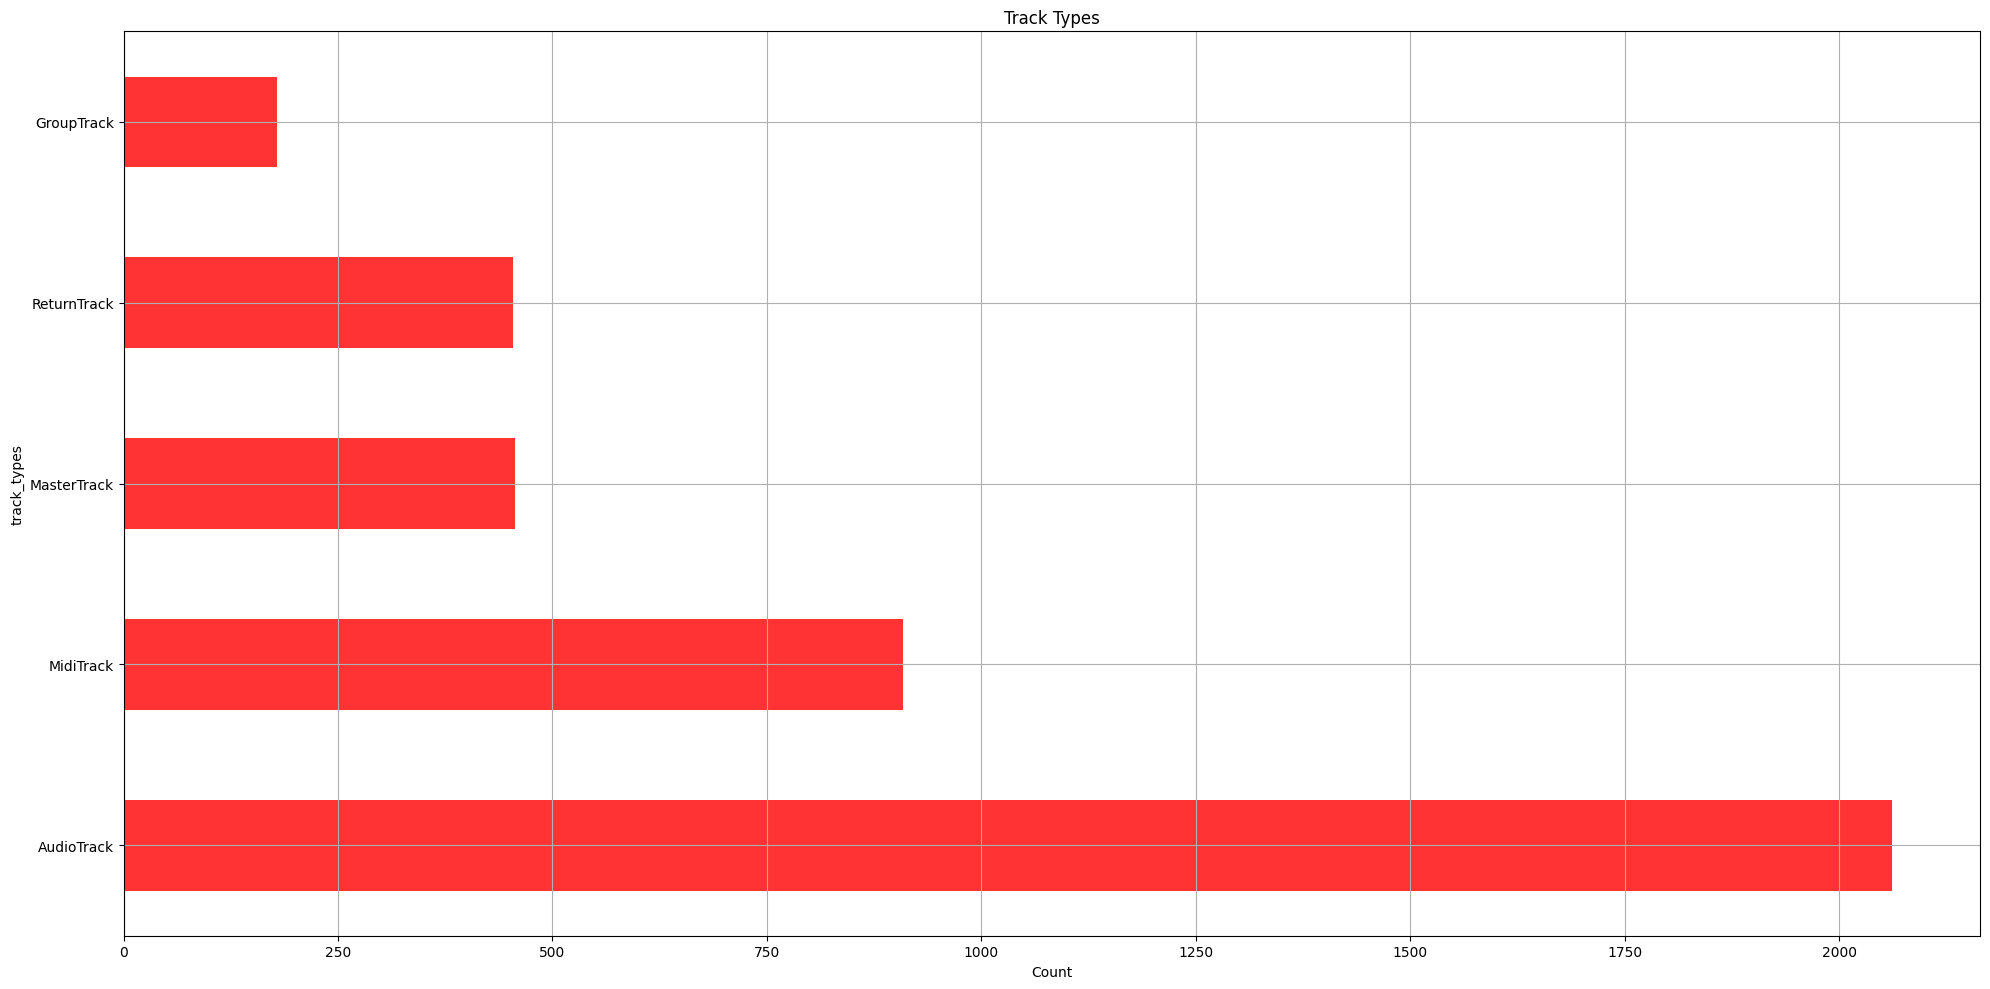

In [4]:
def plot_counters(
    counters,
    top_n=10,
    figsize=(12, 6),
    grid=True,
    alpha=0.8,
    cmap_name='rainbow',
):
  """Generates bar charts for counters, with extensive customization options."""

  num_counters = len(counters) if counters else 0
  cmap = plt.get_cmap(cmap_name, num_counters)  # Use plt.get_cmap
  bar_colors = [cmap(i) for i in range(num_counters)]

  for i, (name, counter) in enumerate(counters.items()):
    print(f'Counter: {name} has {len(counter)} entries')
    if not counter or all(v == 0 for v in counter.values()):
      print(f"WARNING: Counter '{name}' is empty or all zeros. Skipping plot.")
      continue

    df = pd.DataFrame.from_dict(
        counter, orient='index', columns=['count']
    ).sort_values('count', ascending=False)
    df = df.head(top_n)

    title = name.replace('_', ' ').title()
    if top_n:
      title += f' (Top {top_n})'

    df.plot.barh(
        y='count',
        color=[bar_colors[i]],  # Use list of a single color
        figsize=figsize,
        alpha=alpha,
        grid=grid,
        title=title,
        xlabel='Count',
        ylabel=name,
        legend=False,
    )
    plt.tight_layout()
    plt.show()


plot_counters(project_counters, top_n=None, figsize=(20, 10))


In [6]:
def query_projects_by_plugin(project_info, plugin_type, preset_name):
  project_keys = []
  assert plugin_type in ['PluginDevice', 'AuPluginDevice']
  for fname, v in project_info.items():
    for track in v['tracks']:
      for dev in track['devices']:
        if dev['type'] == plugin_type and dev['preset'] == preset_name:
            project_keys.append('%s-%d' % (fname, track['index']))

  return project_keys

query_projects_by_plugin(project_info, "PluginDevice", "Neutron 3")

['_acoustic jams sorted-33', '_two track jams-31', 'house acoustic jam-1']

In [7]:
#@title Some checks
DEPRECATED_PLUGINS = ["Ozone 8", "Ozone 6"] # "Neutron 3"
for vst in DEPRECATED_PLUGINS:
  print(f'CHECK\t| {vst} should not be an any projects', end='')
  assert 0 == len(query_projects_by_plugin(project_info, "PluginDevice", vst))
  print('...and is not')

ONLY_A10_AUDIO_UNIT = ['Crystallizer', 'GS-201']
for au in ONLY_A10_AUDIO_UNIT:
  print(f'NOTE\t| {au} is only available as a 32 bit audio unit')


CHECK	| Ozone 8 should not be an any projects...and is not
CHECK	| Ozone 6 should not be an any projects...and is not
NOTE	| Crystallizer is only available as a 32 bit audio unit
NOTE	| GS-201 is only available as a 32 bit audio unit


#### TODO: FIX Audiounit plugins [DONE??! this is old delete]
* dimensions 4: on a10, swap out iZotope Ozone 5 AU for VST
* slow burn mixdown: swap out Maschine 2 and Komplete Kontrol AU for VST
* brady-jake jam +extra day 2: swap out Massive AU for VST
* brady-jake jam 0: swap out Massive AU for VST
* acoustic sad vox (multiple): swap out iZotope Nectar 2 AU for VST

**TODO**:add above check that the only 2 audiounites are ONLY_A10_AUDIO_UNIT


In [12]:
#@title Query
plugin_type = "PluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "Reaktor 6 FX" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching preset: Reaktor 6 FX

2021 mac13 template-1
2021 mac13 template-2
MORE of a jam-10
NEW YTEMPLATE-2
a-1
a-2
aciustic mac feedback-1
aciustic mac feedback-2
acoustic jam psych-1
acoustrunkv2-2
acoustrunkv2-3
acoustrunkv2-4
acoustrunkv2-5
acoustrunkvo-1
acoustrunkvo-2
autotune sad minor guitar-3
bnchmark-1
bnchmark-2
current template-2
death flutes-6
garage rock template-3
guitar live-1
guitar vox loops downmixed-1
guitar vox loops downmixed-2
guitar vox loops-1
guitar vox loops-2
hipohopy-1
hipohopy-2
loose acousitc distorted vox loop jam-1
makings of a jam-2
new roume jaamz-1
psychccy acoust trip loops-3
sad verse psych-1
sad verse psych-2
single trackpyshch new roume accoustic blah-1
slow dark garage jaaam-3
soul sample-3
template_2020 2-1
template_2020 2-2
template_2020-1
template_2020-2
traoppy-6
